### Batch Normalization is the technique in which the output of the given layer is also normalized so that the convergence is faster and more stable

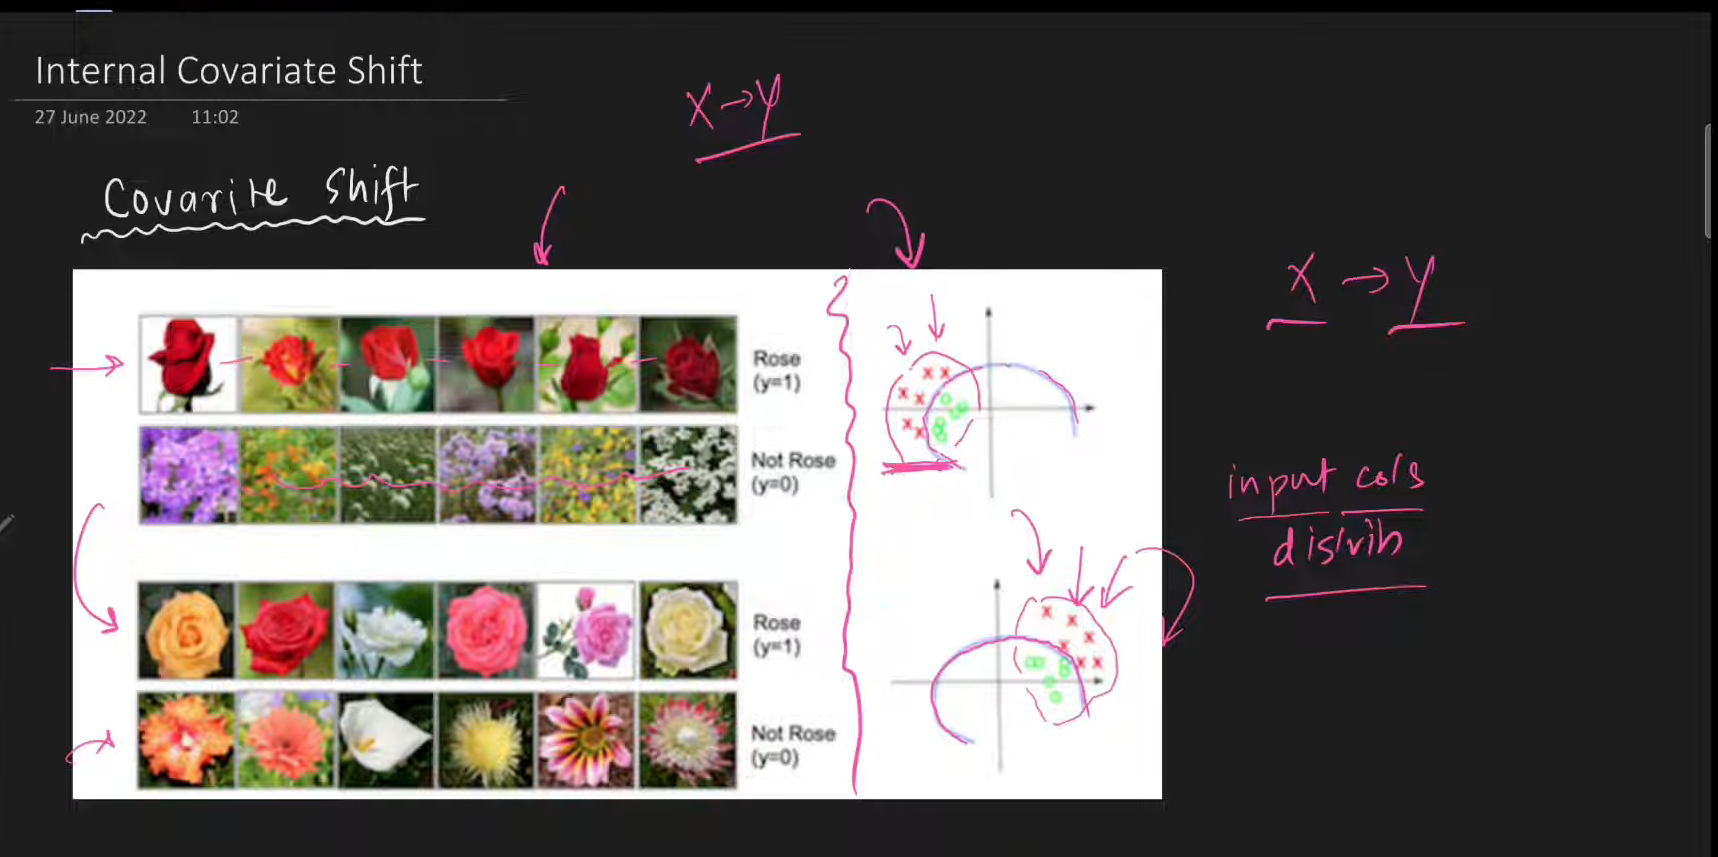

# Batch Normalization in Deep Learning

> Topic: Batch Normalization (BatchNorm)
>
> Video: CampusX — Batch Normalization in Deep Learning | Batch Learning in Keras

---

## 1. What is Batch Normalization?

Batch Normalization (BatchNorm) is a technique used in neural networks to normalize the activations of a layer during training.

The basic idea is:

$$
x \rightarrow \text{Normalization} \rightarrow \text{Neural Network Layer}
$$

Instead of allowing activations to have arbitrary distributions, BatchNorm keeps them in a more controlled range.

It is particularly useful for:

- Faster training
- More stable training
- Allowing larger learning rates
- Reducing sensitivity to initialization
- Helping with vanishing/exploding gradients
- Providing some regularization

---

# 2. Why Do We Need Batch Normalization?

Consider a neural network:

$$
X \rightarrow Z_1 \rightarrow A_1
\rightarrow Z_2 \rightarrow A_2
\rightarrow Z_3 \rightarrow A_3
$$

where:

$$
Z = WX + b
$$

and:

$$
A = f(Z)
$$

During training, the weights of previous layers continuously change.

Therefore, the distribution of the inputs received by subsequent layers also keeps changing.

This can make optimization difficult.

---

# 3. Internal Covariate Shift

The original motivation for BatchNorm is often explained using the concept of:

> Internal Covariate Shift

Suppose Layer 2 receives:

$$
X_2
$$

The distribution of $X_2$ depends on the weights of Layer 1.

But Layer 1's weights are changing during training.

Therefore:

$$
P(X_2)
$$

also keeps changing.

Layer 2 is therefore constantly trying to learn from a changing input distribution.

### Intuition

Imagine you are learning to predict house prices.

Initially:

```text
House size → 100–200 m²

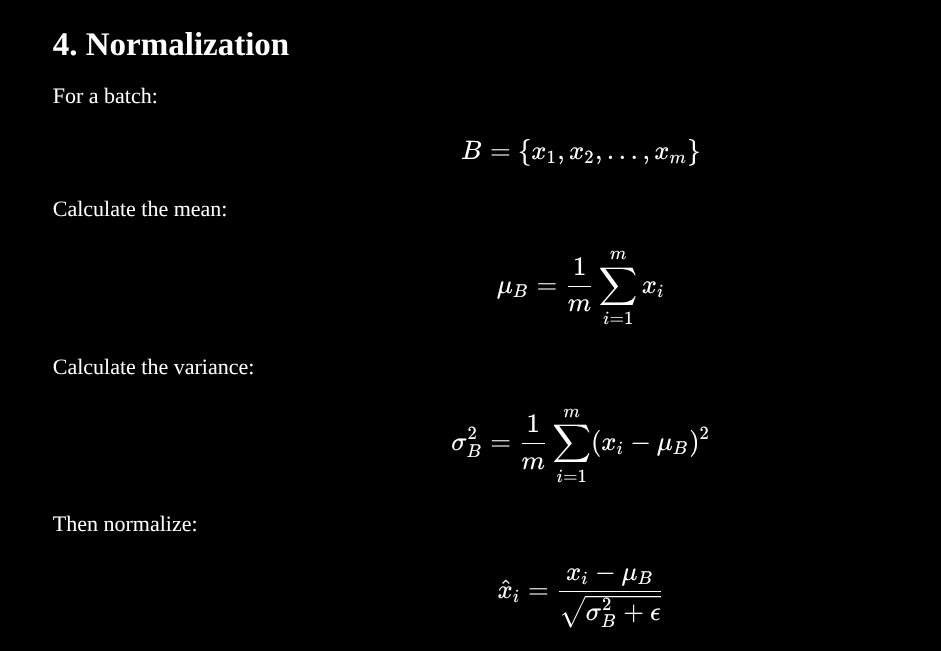

## Advantaytages of batch normalization

1) #### Stable hyperparameter - wider range of rows
2) #### faster learning rates
3) #### Regulizer not so good but some descent amount of regularizations happens
4) #### Weight initilization effects

# Keras Implimentation

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
from tensorflow.keras.layers import BatchNormalization


In [9]:
model = Sequential()
model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(3,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(3,activation='sigmoid'))


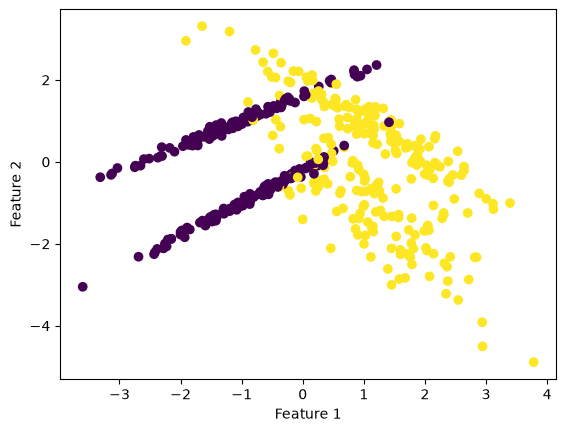

In [12]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=1,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [15]:
from tensorflow import keras
from keras.layers import Dense
from keras import Sequential
from tensorflow.keras.layers import BatchNormalization

In [18]:
model = Sequential()
model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/run/media/darshchouhan/New Volume/DL-Algorithm/venv/lib64/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [23]:
history=model.fit(X,y,validation_split=0.24,epochs=200)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9342 - loss: 0.2169 - val_accuracy: 0.8500 - val_loss: 0.3111
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9316 - loss: 0.2170 - val_accuracy: 0.8500 - val_loss: 0.3107
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9342 - loss: 0.2174 - val_accuracy: 0.8500 - val_loss: 0.3123
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9342 - loss: 0.2168 - val_accuracy: 0.8500 - val_loss: 0.3115
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9342 - loss: 0.2169 - val_accuracy: 0.8500 - val_loss: 0.3111
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9342 - loss: 0.2171 - val_accuracy: 0.8500 - val_loss: 0.3120
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9342 - loss: 0.2167 - val_accuracy: 0.8500 - val_loss: 0.3115
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9342 - loss: 0.2167 - val_accuracy: 0.8500 

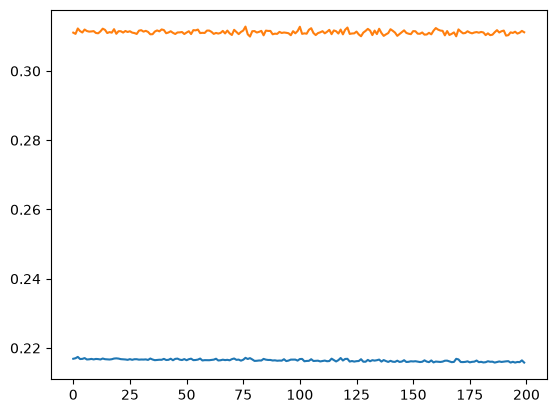

In [24]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [25]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

/run/media/darshchouhan/New Volume/DL-Algorithm/venv/lib64/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [26]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [27]:
history=model.fit(X,y,validation_split=0.24,epochs=200)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5289 - loss: 0.8704 - val_accuracy: 0.5833 - val_loss: 0.6736
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5579 - loss: 0.8214 - val_accuracy: 0.6000 - val_loss: 0.6609
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6132 - loss: 0.7821 - val_accuracy: 0.6167 - val_loss: 0.6467
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6289 - loss: 0.7159 - val_accuracy: 0.6417 - val_loss: 0.6286
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6553 - loss: 0.6915 - val_accuracy: 0.6667 - val_loss: 0.6110
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6816 - loss: 0.6256 - val_accuracy: 0.7083 - val_loss: 0.5930
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7000 - loss: 0.5987 - val_accuracy: 0.7250 - val_loss: 0.5763
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7421 - loss: 0.5372 - val_accuracy: 0.7500 -

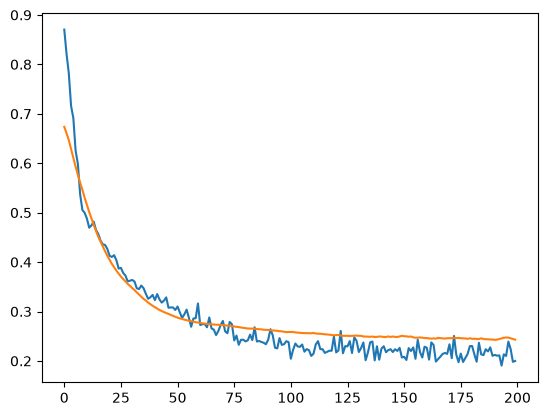

In [28]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])